#### 1. Load data, 2. Dataset overview, 3. Data quality checks, 4. Price trend, 5. Trading volume, 6. Moving averages, 7. Save cleaned data.

In [ ]:
# Load the raw GOOG stock data downloaded from Yahoo Finance
import pandas as pd
print(pd.__version__)

3.0.6


In [ ]:
# parse_dates converts the Date column to real datetime values
# index_col makes Date the index, which is convenient for time series work

df = pd.read_csv("../data/raw_data/google_stock_price_raw.csv", parse_dates=["Date"], index_col="Date")

print(df.shape)
df.head()

(1939, 6)


,Open,High,Close,Low,Adj Close,Volume
Date,,,,,,
2019-01-02,50.828499,52.616001,52.292500,50.785500,51.801849,30652000
2019-01-03,52.049999,52.848999,50.803001,50.703499,50.326332,36822000
2019-01-04,51.629501,53.542000,53.535500,51.370899,53.033192,41878000
2019-01-07,53.575001,53.700001,53.419498,52.737999,52.918270,39638000
2019-01-08,53.805500,54.228001,53.813999,53.026501,53.309071,35298000


In [ ]:
# Check row count, date range, data types and non-null counts per column
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1939 entries, 2019-01-02 to 2026-09-18
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1939 non-null   float64
 1   High       1939 non-null   float64
 2   Close      1939 non-null   float64
 3   Low        1939 non-null   float64
 4   Adj Close  1939 non-null   float64
 5   Volume     1939 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 106.0 KB


In [ ]:
# Summary statistics (count, mean, min, max, quartiles) for every column
# Used to sanity check the price and volume ranges
df.describe()

,Open,High,Close,Low,Adj Close,Volume
count,1939.000000,1939.000000,1939.000000,1939.000000,1939.000000,1.939000e+03
mean,144.005489,145.712934,144.139269,142.449775,143.227243,2.640833e+07
std,80.633550,81.656446,80.727096,79.651055,80.786079,1.228002e+07
min,50.828499,52.374500,50.803001,50.676800,50.326332,6.138200e+06
25%,87.362499,88.474751,87.333248,86.614998,86.513821,1.851110e+07
50%,129.440002,130.770004,129.121002,127.775002,127.909477,2.362740e+07
75%,168.862503,170.425003,168.510002,166.480003,167.268456,3.076200e+07
max,397.059998,404.470001,399.040009,393.670013,398.541260,1.241400e+08


In [ ]:
# Data quality checks: missing values and repeated dates
print("Missing values:\n", df.isnull().sum())
print("Duplicate dates:", df.index.duplicated().sum())

Missing values:
 Open         0
High         0
Close        0
Low          0
Adj Close    0
Volume       0
dtype: int64
Duplicate dates: 0


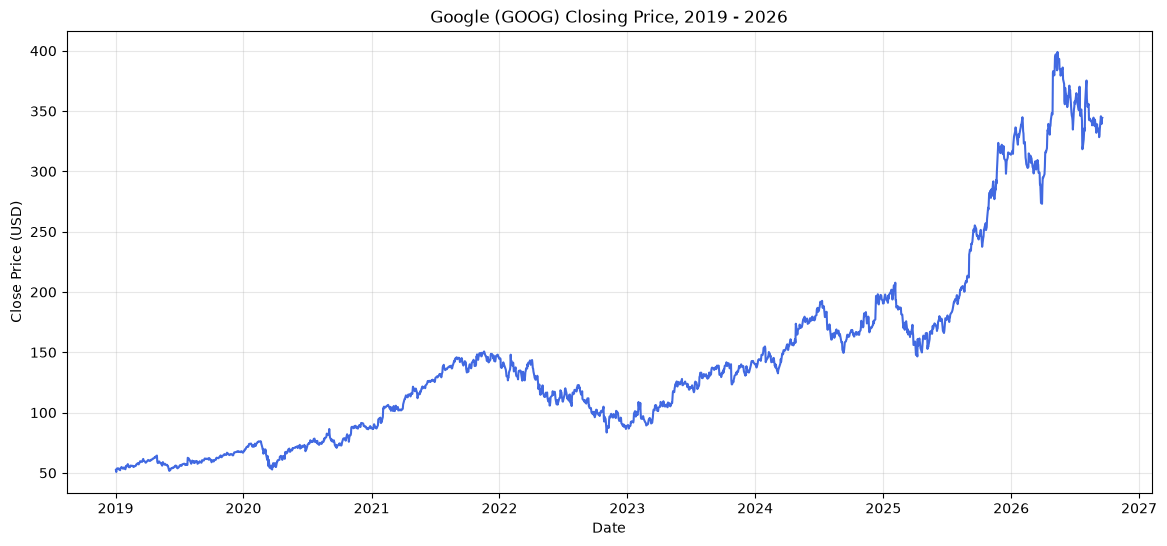

In [ ]:
import matplotlib.pyplot as plt

# Plot the closing price over time to see the overall trend

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], color="royalblue")
plt.title("Google (GOOG) Closing Price, 2019 - 2026")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.grid(alpha=0.3)

plt.savefig("../results/plots/close_price_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

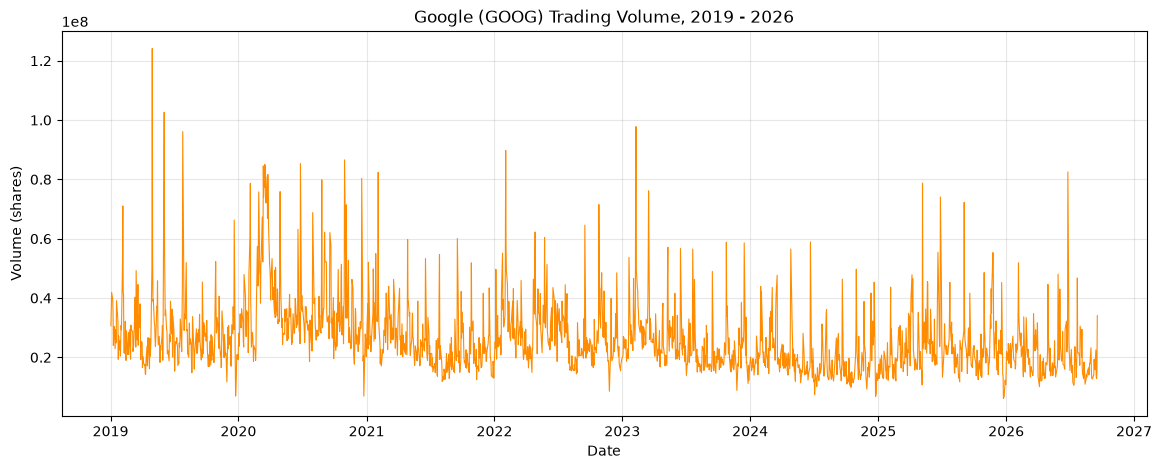

In [ ]:
# Plot trading volume to see how many shares were traded each day

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Volume"], color="darkorange", linewidth=0.8)
plt.title("Google (GOOG) Trading Volume, 2019 - 2026")
plt.xlabel("Date")
plt.ylabel("Volume (shares)")
plt.grid(alpha=0.3)

plt.savefig("../results/plots/volume_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

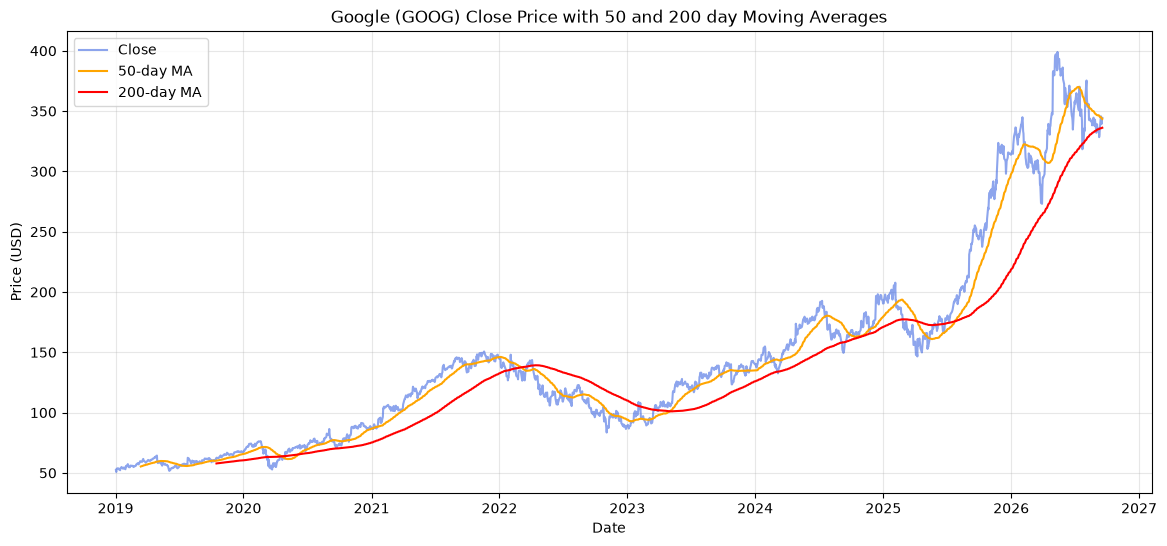

In [ ]:
# Moving averages smooth out daily noise so the trend is easier to see
# 50-day = short/medium term trend, 200-day = long term trend
# These columns are only for visualisation, not for the model

df["MA_50"] = df["Close"].rolling(window=50).mean()
df["MA_200"] = df["Close"].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Close", color="royalblue", alpha=0.6)
plt.plot(df.index, df["MA_50"], label="50-day MA", color="orange")
plt.plot(df.index, df["MA_200"], label="200-day MA", color="red")
plt.title("Google (GOOG) Close Price with 50 and 200 day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("../results/plots/moving_averages.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Save the cleaned dataset for the preprocessing phase
# Keep only the original 6 columns (drops the MA columns added for plotting)
original_columns = ["Open", "High", "Close", "Low", "Adj Close", "Volume"]

# Sort by date so the time series is in chronological order
cleaned_df = df[original_columns].sort_index()

cleaned_df.to_csv("../data/cleaned_data/google_stock_price_cleaned.csv")

print(cleaned_df.shape)
cleaned_df.head()

(1939, 6)


,Open,High,Close,Low,Adj Close,Volume
Date,,,,,,
2019-01-02,50.828499,52.616001,52.292500,50.785500,51.801849,30652000
2019-01-03,52.049999,52.848999,50.803001,50.703499,50.326332,36822000
2019-01-04,51.629501,53.542000,53.535500,51.370899,53.033192,41878000
2019-01-07,53.575001,53.700001,53.419498,52.737999,52.918270,39638000
2019-01-08,53.805500,54.228001,53.813999,53.026501,53.309071,35298000


##### "From the exploratory analysis, I observed that GOOG had a strong long-term upward trend but with significant periods of volatility. There was a sharp decline in 2020, another major decline in 2022, followed by a steady recovery from 2023 and a strong price increase during 2025–2026. Trading volume was relatively noisy without a consistent long-term trend, but there were noticeable spikes during major market events."